# 🤖 IMDb Movie Review Sentiment Analysis using BERT

## Project Overview

This project builds a sentiment analysis classifier using **BERT (Bidirectional Encoder Representations from Transformers)**, a transformer-based language model developed by Google.

Unlike the Classical NLP approach that relies on handcrafted preprocessing and TF-IDF feature engineering, BERT learns contextual word representations directly from raw text through self-attention mechanisms.

The objective of this notebook is to fine-tune a pre-trained **bert-base-uncased** model for binary sentiment classification on the IMDb Movie Reviews dataset and compare its performance with the Classical NLP baseline.

## 🎯 Objectives

- Fine-tune a pre-trained BERT model for sentiment classification.
- Understand the BERT fine-tuning workflow using Hugging Face Transformers.
- Compare transformer-based NLP with the Classical TF-IDF approach.
- Evaluate model performance using multiple classification metrics.
- Save the trained model for future inference.

> **⚠️ Note**
>
> Fine-tuning BERT is computationally intensive. For faster training, use a **GPU runtime** (Google Colab → Runtime → Change runtime type → GPU). The notebook also supports loading a previously saved model to skip retraining.

# 🧹 Why Minimal Preprocessing?

Traditional NLP pipelines require multiple preprocessing steps such as HTML removal, stopword removal, lemmatization, and TF-IDF feature extraction.

BERT does not require these handcrafted transformations because it learns contextual representations directly from tokenized text.

Only label encoding is required before training.

# 📦 Import Required Libraries

The project uses the Hugging Face Transformers ecosystem together with PyTorch for model training and Scikit-learn for evaluation.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
from datasets import Dataset

from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 📊 Dataset

The IMDb Movie Reviews dataset contains **50,000** balanced movie reviews labeled as Positive and Negative.

Unlike the previous Classical NLP pipeline, this notebook feeds raw review text directly into BERT without performing extensive preprocessing.

In [ ]:
url = "https://raw.githubusercontent.com/ankith-b-kumar/IMBD-Movie-Reviews-Sentimental-Analysis-Classification-/main/Dataset/IMDB%20Dataset.csv"

df = pd.read_csv(url)

# 🏷️ Label Encoding

In [ ]:
le = LabelEncoder()

df["label"] = le.fit_transform(df["sentiment"])

# ✂️ Train-Test Split

The dataset is divided into training and testing subsets to evaluate the model on unseen reviews while preserving generalization performance.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df["review"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# 🔄 Convert to Hugging Face Dataset

The Pandas DataFrames are converted into Hugging Face Dataset objects, enabling efficient tokenization, batching, and training using the Trainer API.

In [ ]:
train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

# ♻️ Training vs. Loading a Saved Model

This notebook supports two execution modes:

- **Train a new BERT model** by setting `USE_SAVED_MODEL = False`.
- **Load a previously fine-tuned model** by setting `USE_SAVED_MODEL = True`.

Loading a saved model is significantly faster and avoids repeating the fine-tuning process.

In [ ]:
USE_SAVED_MODEL = False

LOCAL_MODEL_PATH = "./bert_sentiment_model"

# 🔤 Tokenization

Unlike TF-IDF, BERT uses a WordPiece tokenizer that converts text into subword tokens while preserving contextual meaning.

The tokenizer also generates attention masks and input IDs required by the transformer model.

In [ ]:
if USE_SAVED_MODEL:
    tokenizer = BertTokenizer.from_pretrained(LOCAL_MODEL_PATH)
else:
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=256
    )

In [ ]:
train_dataset = train_dataset.map(tokenize, batched=True)

test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

# 🧠 Load Pre-trained BERT Model

The project fine-tunes the **bert-base-uncased** model using Hugging Face Transformers.

Instead of training a language model from scratch, transfer learning allows BERT to adapt its existing language understanding to sentiment classification.

In [ ]:
if USE_SAVED_MODEL:
    model = BertForSequenceClassification.from_pretrained(LOCAL_MODEL_PATH)
else:
    model = BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# 📈 Evaluation Metrics

Model performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Evaluating multiple metrics provides a more comprehensive assessment than accuracy alone.

In [ ]:
def compute_metrics(pred):

    labels = pred.label_ids

    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average="binary"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# 🚀 Fine-Tuning BERT

Training is performed using the Hugging Face Trainer API.

The model updates its pre-trained weights using the IMDb dataset while monitoring validation performance after each epoch.

In [ ]:
import os

os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

In [ ]:
# !pip install tensorboard

In [ ]:
if not USE_SAVED_MODEL:
    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        num_train_epochs=3,
        weight_decay=0.01,
        logging_strategy="steps",
        logging_steps=100,
        fp16=True,
        report_to="tensorboard"
    )

# 👨‍🏫 Create the Hugging Face Trainer

In [ ]:
if USE_SAVED_MODEL:
    trainer = Trainer(
        model=model,
    )
else:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=compute_metrics,
    )

# 🏋️ Train the Model

In [ ]:
if not USE_SAVED_MODEL:
    trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.210912,0.202296,0.923300,0.906316,0.944200,0.924870
2,0.124364,0.232956,0.919600,0.955691,0.880000,0.916285
3,0.071926,0.264863,0.929000,0.919273,0.940600,0.929814


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
if not USE_SAVED_MODEL:
    trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.071926,0.264863,3,0.929000,0.919273,0.940600,0.929814


# 💾 Saving the Fine-Tuned Model

The trained model and tokenizer are saved locally.

This allows future inference without repeating the computationally expensive fine-tuning process.

Note: This cell is used only after fine-tuning a new model. It does not need to be executed when using the previously saved model.

In [ ]:
if not USE_SAVED_MODEL:

    model.save_pretrained(LOCAL_MODEL_PATH)
    tokenizer.save_pretrained(LOCAL_MODEL_PATH)

    print(f"Model saved to: {LOCAL_MODEL_PATH}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./bert_sentiment_model


In [ ]:
import shutil

shutil.make_archive("bert_sentiment_model", "zip", LOCAL_MODEL_PATH)

In [ ]:
# Save the trained model config to your local directory.
from google.colab import files

files.download("bert_sentiment_model.zip")

# 🎬 Predicting Unseen Reviews

After training, the fine-tuned model is tested on custom movie reviews to verify its ability to generalize beyond the training dataset.

In [ ]:
review = "Worst movie ever. Waste of time."

inputs = tokenizer(
    review,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

# Move inputs to GPU
inputs = {k: v.to(model.device) for k, v in inputs.items()}

model.eval()

with torch.no_grad():
    outputs = model(**inputs)

prediction = torch.argmax(outputs.logits, dim=1)

# Move prediction back to CPU before converting to NumPy
prediction = prediction.cpu()

print(le.inverse_transform(prediction.numpy()))

['negative']


# 📊 Evaluation Beyond Accuracy

In addition to overall accuracy, Precision, Recall, F1-score, and the Confusion Matrix are analyzed to better understand classification performance and error distribution.

Note: This cell is also used only after fine-tuning a new model. It does not need to be executed when using the previously saved model.

In [ ]:
from sklearn.metrics import classification_report

predictions = trainer.predict(test_dataset)

y_pred = predictions.predictions.argmax(axis=1)

print(classification_report(y_test, y_pred, target_names=le.classes_))

              precision    recall  f1-score   support

    negative       0.94      0.92      0.93      5000
    positive       0.92      0.94      0.93      5000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



# 📉 Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)


[[4587  413]
 [ 297 4703]]


# 🔍 Model Performance Discussion

The fine-tuned BERT model demonstrates strong performance across both sentiment classes.

The confusion matrix shows balanced predictions, while Precision, Recall, and F1-score confirm that the model generalizes well without relying solely on overall accuracy.

Compared with the Classical NLP baseline, BERT leverages contextual language understanding instead of manually engineered textual features.

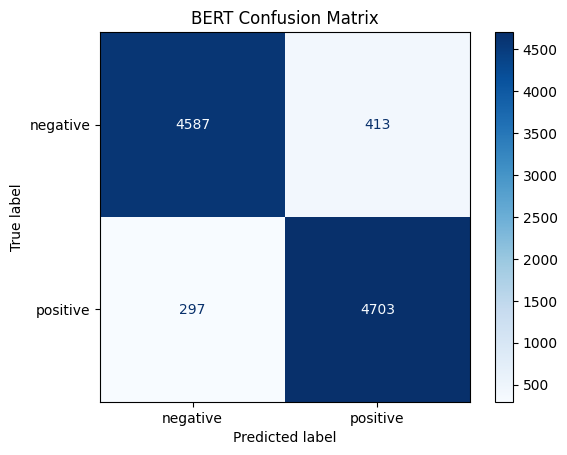

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=le.classes_,
    cmap="Blues"
)

plt.title("BERT Confusion Matrix")
plt.show()

## Interpretability

Unlike Logistic Regression, BERT does not assign easily interpretable feature coefficients.

Instead, it learns contextual representations through multiple transformer layers and self-attention mechanisms, trading interpretability for improved language understanding.

## Key Takeaways

- Fine-tuning pre-trained transformer models eliminates the need for extensive handcrafted preprocessing.
- Transfer learning enables BERT to achieve strong sentiment classification performance with minimal feature engineering.
- Comparing this notebook with the Classical NLP implementation highlights the evolution from manual feature extraction to contextual language representations.